In [1]:
import wrds
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as subplots

In [14]:
db = wrds.Connection(wrds_username="zhouzhou928")

Loading library list...
Done


In [25]:
query = """
SELECT tic, conm, datadate, fyear, revt, ni, at, lt, act, lct, seq
FROM comp.funda
WHERE tic IN ('AAPL','MSFT','GOOGL','AMZN')
AND fyear BETWEEN 2015 AND 2023
AND indfmt='INDL' AND datafmt='STD' AND consol='C'
ORDER BY tic, fyear;
"""
df = db.raw_sql(query)
df['year'] = df['fyear'].astype(int)

In [27]:
print("=== Raw Data Sample ===")
display(df.head(10))

=== Raw Data Sample ===


,tic,conm,datadate,fyear,revt,ni,at,lt,act,lct,seq,year,profit_margin,roe,roa,debt_asset,current_ratio
0,AAPL,APPLE INC,2015-09-30,2015,233715.0,53394.0,290479.0,171124.0,89378.0,80610.0,119355.0,2015,22.845774,44.735453,18.381363,58.910971,1.108771
1,AAPL,APPLE INC,2016-09-30,2016,215091.0,45687.0,321686.0,193437.0,106869.0,79006.0,128249.0,2016,21.240777,35.62367,14.202359,60.132241,1.352669
2,AAPL,APPLE INC,2017-09-30,2017,229234.0,48351.0,375319.0,241272.0,128645.0,100814.0,134047.0,2017,21.092421,36.070184,12.882641,64.284515,1.276063
3,AAPL,APPLE INC,2018-09-30,2018,265359.0,59531.0,365725.0,258578.0,131339.0,116866.0,107147.0,2018,22.434136,55.560118,16.277531,70.702851,1.123843
4,AAPL,APPLE INC,2019-09-30,2019,260174.0,55256.0,338516.0,248028.0,162819.0,105718.0,90488.0,2019,21.238095,61.064451,16.32301,73.26921,1.540126
5,AAPL,APPLE INC,2020-09-30,2020,274515.0,57411.0,323888.0,258549.0,143713.0,105392.0,65339.0,2020,20.913611,87.866359,17.725572,79.826668,1.363604
6,AAPL,APPLE INC,2021-09-30,2021,365817.0,94680.0,351002.0,287912.0,134836.0,125481.0,63090.0,2021,25.881793,150.071327,26.974205,82.025743,1.074553
7,AAPL,APPLE INC,2022-09-30,2022,394328.0,99803.0,352755.0,302083.0,135405.0,153982.0,50672.0,2022,25.309641,196.958873,28.292441,85.635356,0.879356
8,AAPL,APPLE INC,2023-09-30,2023,383285.0,96995.0,352583.0,290437.0,143566.0,145308.0,62146.0,2023,25.306234,156.076015,27.509835,82.374079,0.988012
9,AMZN,AMAZON.COM INC,2015-12-31,2015,107006.0,596.0,65444.0,52060.0,36474.0,33899.0,13384.0,2015,0.556978,4.453078,0.910702,79.548927,1.075961


In [28]:
df['profit_margin'] = (df['ni'] / df['revt']) * 100
df['roe'] = (df['ni'] / df['seq']) * 100
df['roa'] = (df['ni'] / df['at']) * 100
df['debt_asset'] = (df['lt'] / df['at']) * 100
df['current_ratio'] = df['act'] / df['lct']

In [29]:
df['revt_growth'] = df.groupby('tic')['revt'].pct_change() * 100
df['ni_growth'] = df.groupby('tic')['ni'].pct_change() * 100

In [30]:
industry = df.groupby('year').agg({
    'revt': 'mean',
    'ni': 'mean',
    'profit_margin': 'mean',
    'roe': 'mean',
    'roa': 'mean'
}).reset_index()
industry['tic'] = 'INDUSTRY'
industry['conm'] = 'TECH INDUSTRY AVG'

In [31]:
final = pd.concat([df, industry], ignore_index=True)

In [32]:
summary_2023 = final[final['year'] == 2023][[
    'tic', 'conm', 'revt', 'ni', 'profit_margin', 'roe', 'roa'
]].round(2)
print("=== 2023 Financial Summary Table ===")
display(summary_2023)

=== 2023 Financial Summary Table ===


,tic,conm,revt,ni,profit_margin,roe,roa
8,AAPL,APPLE INC,383285.0,96995.0,25.31,156.08,27.51
17,AMZN,AMAZON.COM INC,574785.0,30425.0,5.29,15.07,5.76
26,GOOGL,ALPHABET INC,307394.0,73795.0,24.01,26.25,18.34
35,MSFT,MICROSOFT CORP,211915.0,72361.0,34.15,35.09,17.56
44,INDUSTRY,TECH INDUSTRY AVG,369344.75,68394.0,22.19,58.12,17.29


In [33]:
final.to_csv('wrds_final_data.csv', index=False)
print("✅ Data saved successfully")

✅ Data saved successfully


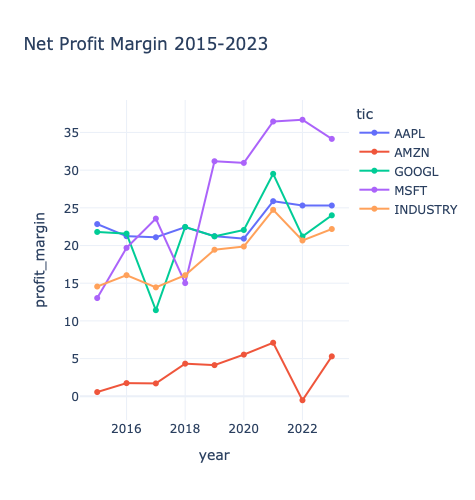

In [44]:
fig = px.line(final, x='year', y='profit_margin', color='tic',
              markers=True, template='plotly_white',
              title='Net Profit Margin 2015-2023')
fig.update_layout(height=500)
fig.show()

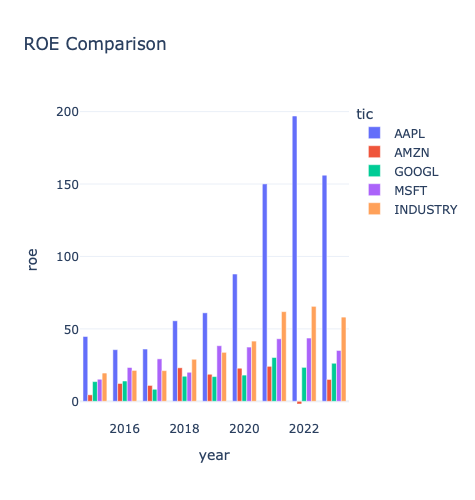

In [45]:
fig = px.bar(final, x='year', y='roe', color='tic', barmode='group',
             template='plotly_white', title='ROE Comparison')
fig.update_layout(height=500)
fig.show()

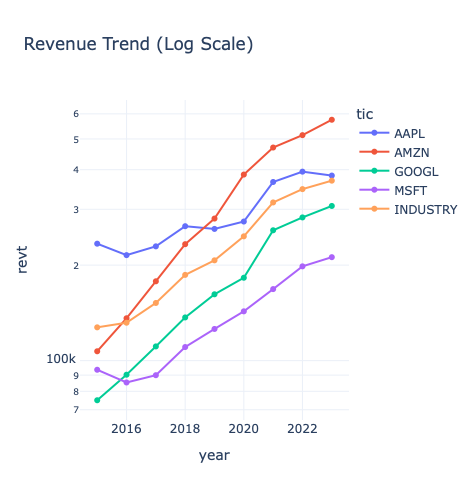

In [46]:
fig = px.line(final, x='year', y='revt', color='tic',
              markers=True, template='plotly_white',
              title='Revenue Trend (Log Scale)')
fig.update_layout(yaxis_type="log", height=500)
fig.show()

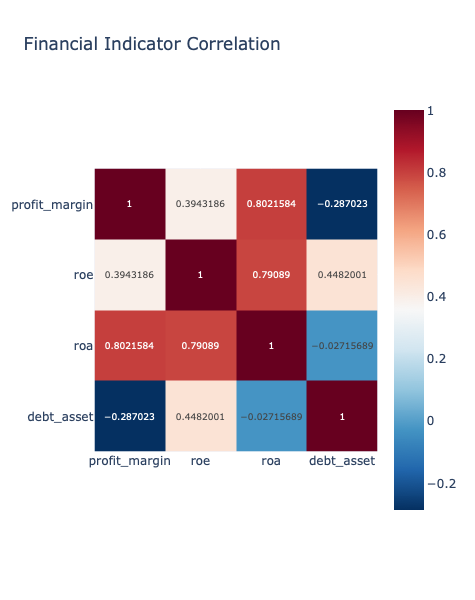

In [47]:
corr = df[['profit_margin', 'roe', 'roa', 'debt_asset']].corr()
fig = px.imshow(corr, text_auto=True, color_continuous_scale='RdBu_r',
                title='Financial Indicator Correlation')
fig.update_layout(height=600)
fig.show()

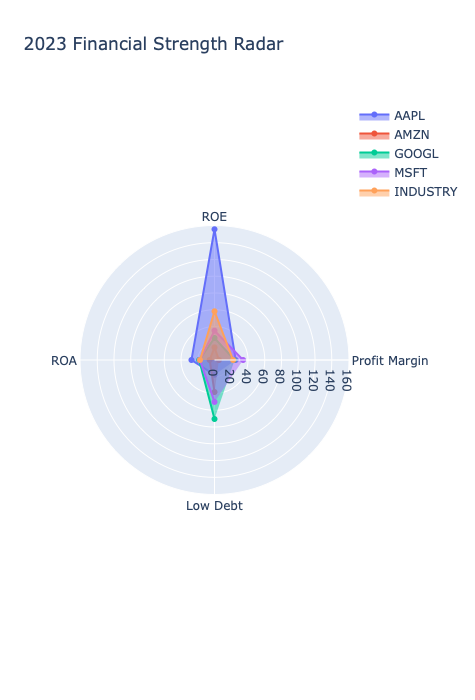

In [48]:
latest = final[final['year'] == 2023].copy()
fig = go.Figure()
for _, r in latest.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[r.profit_margin, r.roe, r.roa, 100-r.debt_asset],
        theta=['Profit Margin', 'ROE', 'ROA', 'Low Debt'],
        fill='toself', name=r.tic
    ))
fig.update_layout(title='2023 Financial Strength Radar', height=700)
fig.show()

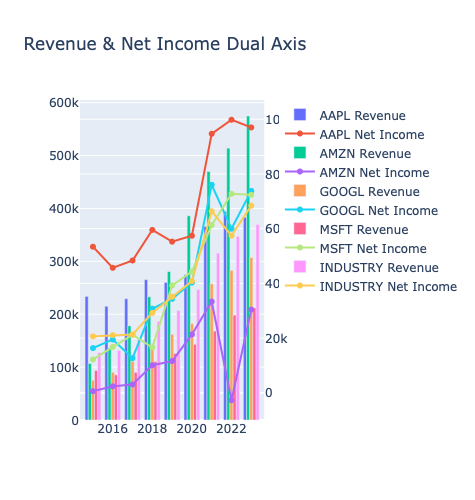

In [49]:
fig = subplots.make_subplots(specs=[[{"secondary_y": True}]])
for t in final['tic'].unique():
    d = final[final['tic'] == t]
    fig.add_trace(go.Bar(x=d.year, y=d.revt, name=f'{t} Revenue'), secondary_y=False)
    fig.add_trace(go.Scatter(x=d.year, y=d.ni, name=f'{t} Net Income'), secondary_y=True)
fig.update_layout(title='Revenue & Net Income Dual Axis', height=500)
fig.show()

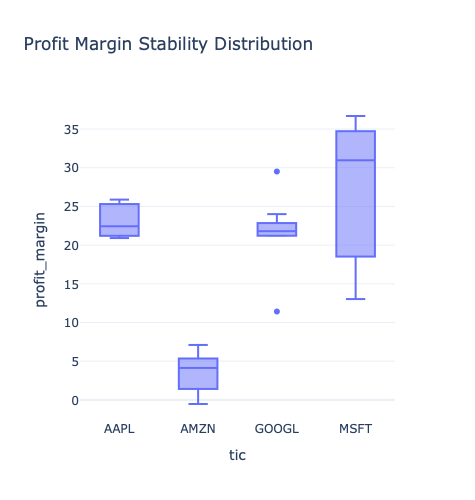

In [50]:
fig = px.box(df, x='tic', y='profit_margin',
             title='Profit Margin Stability Distribution',
             template='plotly_white')
fig.update_layout(height=500)
fig.show()

In [51]:
print("""
=== KEY INSIGHTS ===
1. AAPL has the highest and most stable profit margin.
2. MSFT leads in ROE and efficiency.
3. AMZN has high revenue but lower profitability.
4. GOOGL is consistent and balanced.
5. All companies outperform the industry average.
""")


=== KEY INSIGHTS ===
1. AAPL has the highest and most stable profit margin.
2. MSFT leads in ROE and efficiency.
3. AMZN has high revenue but lower profitability.
4. GOOGL is consistent and balanced.
5. All companies outperform the industry average.



In [55]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
